# Home Visitations Analytics Pipeline

## 1) Problem Framing

**Business question:** Which home visit factors are associated with (a) better visit outcomes and (b) higher risk of requiring follow-up?

This notebook builds both:
- **Explanatory (causal-style) model** for transparent effect estimates.
- **Predictive model** for reliable out-of-sample performance.

**Primary success metrics**
- Predictive: macro F1 and balanced accuracy for outcome classification.
- Operational risk model: ROC-AUC for `follow_up_needed`.
- Explanatory: sign/magnitude consistency and confidence intervals.

**Decision use**
- Prioritize interventions for visit profiles linked to unfavorable outcomes.
- Assign social workers/resources based on predicted risk and key drivers.

In [14]:
# 2) Data Acquisition
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

DATA_PATH = Path("../datasets/home_visitations.csv")
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(1337, 14)


,visitation_id,resident_id,visit_date,social_worker,visit_type,location_visited,family_members_present,purpose,observations,family_cooperation_level,safety_concerns_noted,follow_up_needed,follow_up_notes,visit_outcome
0,1,1,2023-11-02,SW-04,Routine Follow-Up,Proposed Foster Home,Lopez (Parent); Diaz (Sibling),Visitation for routine follow-up,Visit observations recorded during routine fol...,Neutral,True,False,Follow-up scheduled,Favorable
1,2,1,2023-11-22,SW-12,Routine Follow-Up,Church,Mendoza (Parent); Mendoza (Sibling),Visitation for routine follow-up,Visit observations recorded during routine fol...,Neutral,False,False,NaN,Favorable
2,3,1,2023-12-14,SW-16,Post-Placement Monitoring,Barangay Office,Santos (Parent); Torres (Sibling),Visitation for post-placement monitoring,Visit observations recorded during post-placem...,Uncooperative,False,True,Follow-up scheduled,Unfavorable
3,4,1,2023-12-18,SW-07,Reintegration Assessment,Proposed Foster Home,Cruz (Parent); Mendoza (Sibling),Visitation for reintegration assessment,Visit observations recorded during reintegrati...,Cooperative,False,True,Follow-up scheduled,Needs Improvement
4,5,1,2023-12-24,SW-05,Post-Placement Monitoring,Community Center,NaN,Visitation for post-placement monitoring,Visit observations recorded during post-placem...,Cooperative,False,True,NaN,Unfavorable


In [15]:
# 2) Data Preparation (reproducible)
def prepare_home_visitations(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    # Parse dates
    data["visit_date"] = pd.to_datetime(data["visit_date"], errors="coerce")
    data["visit_year"] = data["visit_date"].dt.year
    data["visit_month"] = data["visit_date"].dt.month
    data["visit_dow"] = data["visit_date"].dt.dayofweek

    # Boolean cleaning
    for c in ["safety_concerns_noted", "follow_up_needed"]:
        data[c] = data[c].astype(str).str.lower().map({"true": 1, "false": 0})

    # Family members feature engineering
    fam = data["family_members_present"].fillna("None").astype(str)
    data["family_present_count"] = np.where(
        fam.str.lower().eq("none"),
        0,
        fam.str.count(";") + 1,
    )

    # Cooperation ordinal score (helps explanatory model)
    coop_map = {
        "Uncooperative": 1,
        "Neutral": 2,
        "Cooperative": 3,
        "Highly Cooperative": 4,
    }
    data["cooperation_score"] = data["family_cooperation_level"].map(coop_map)

    # Normalize target labels
    data["visit_outcome"] = data["visit_outcome"].astype(str).str.strip()
    data["follow_up_needed"] = data["follow_up_needed"].fillna(0).astype(int)

    # Drop high leakage/free-text IDs for primary modeling
    drop_cols = ["visitation_id", "resident_id", "visit_date", "observations", "follow_up_notes", "purpose"]
    data = data.drop(columns=[c for c in drop_cols if c in data.columns])

    return data


df = prepare_home_visitations(df_raw)
print(df.shape)
print(df.isna().mean().sort_values(ascending=False).head(10))
df.head()

(1337, 13)
family_members_present      0.317876
social_worker               0.000000
visit_type                  0.000000
location_visited            0.000000
family_cooperation_level    0.000000
safety_concerns_noted       0.000000
follow_up_needed            0.000000
visit_outcome               0.000000
visit_year                  0.000000
visit_month                 0.000000
dtype: float64


,social_worker,visit_type,location_visited,family_members_present,family_cooperation_level,safety_concerns_noted,follow_up_needed,visit_outcome,visit_year,visit_month,visit_dow,family_present_count,cooperation_score
0,SW-04,Routine Follow-Up,Proposed Foster Home,Lopez (Parent); Diaz (Sibling),Neutral,1,0,Favorable,2023,11,3,2,2
1,SW-12,Routine Follow-Up,Church,Mendoza (Parent); Mendoza (Sibling),Neutral,0,0,Favorable,2023,11,2,2,2
2,SW-16,Post-Placement Monitoring,Barangay Office,Santos (Parent); Torres (Sibling),Uncooperative,0,1,Unfavorable,2023,12,3,2,1
3,SW-07,Reintegration Assessment,Proposed Foster Home,Cruz (Parent); Mendoza (Sibling),Cooperative,0,1,Needs Improvement,2023,12,0,2,3
4,SW-05,Post-Placement Monitoring,Community Center,NaN,Cooperative,0,1,Unfavorable,2023,12,6,0,3


Outcome distribution:
visit_outcome
Favorable            0.412
Needs Improvement    0.282
Inconclusive         0.177
Unfavorable          0.129
Name: proportion, dtype: float64

Follow-up rate:
0.411


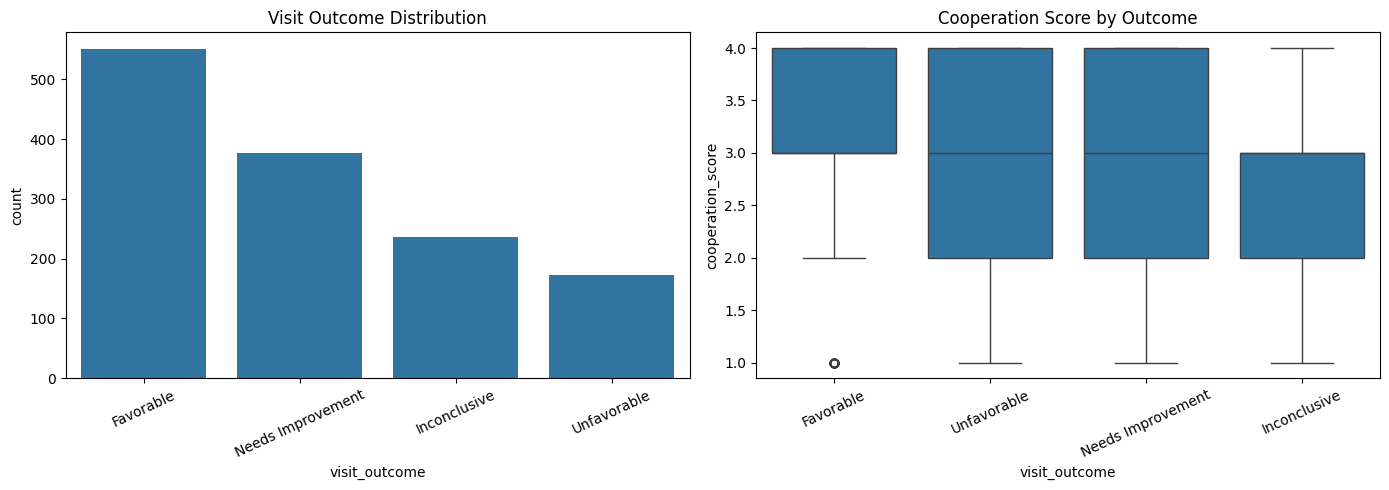

In [16]:
# 3) Exploration
print("Outcome distribution:")
print(df["visit_outcome"].value_counts(normalize=True).round(3))

print("\nFollow-up rate:")
print(df["follow_up_needed"].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="visit_outcome", order=df["visit_outcome"].value_counts().index, ax=axes[0])
axes[0].set_title("Visit Outcome Distribution")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=df, x="visit_outcome", y="cooperation_score", ax=axes[1])
axes[1].set_title("Cooperation Score by Outcome")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

In [17]:
# Shared preprocessing helper
TARGET = "visit_outcome"

X = df.drop(columns=[TARGET])
y = df[TARGET]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Classes:", y.value_counts().to_dict())

Train shape: (1002, 12) Test shape: (335, 12)
Classes: {'Favorable': 551, 'Needs Improvement': 377, 'Inconclusive': 237, 'Unfavorable': 172}


In [18]:
# 4) Explanatory model (causal-style, transparent): logistic regression
causal_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

causal_model.fit(X_train, y_train)
causal_pred = causal_model.predict(X_test)

print("Explanatory model metrics")
print("Macro F1:", round(f1_score(y_test, causal_pred, average="macro"), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, causal_pred), 4))
print(classification_report(y_test, causal_pred))

Explanatory model metrics
Macro F1: 0.4946
Balanced Accuracy: 0.5059
                   precision    recall  f1-score   support

        Favorable       0.73      0.59      0.65       138
     Inconclusive       0.34      0.49      0.40        59
Needs Improvement       0.67      0.53      0.59        95
      Unfavorable       0.29      0.42      0.34        43

         accuracy                           0.53       335
        macro avg       0.50      0.51      0.49       335
     weighted avg       0.59      0.53      0.55       335



In [19]:
# 4-5) Predictive modeling: compare simple strong baselines
candidate_models = {
    "log_reg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2, random_state=42, class_weight="balanced_subsample"
    ),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in candidate_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    f1_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    rows.append({"model": name, "cv_macro_f1_mean": f1_scores.mean(), "cv_macro_f1_std": f1_scores.std()})

results = pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)
results

,model,cv_macro_f1_mean,cv_macro_f1_std
0,log_reg,0.542473,0.028387
1,random_forest,0.488689,0.014925
2,gradient_boosting,0.477684,0.013578


Selected predictive model: log_reg
Macro F1: 0.4946
Balanced Accuracy: 0.5059
                   precision    recall  f1-score   support

        Favorable       0.73      0.59      0.65       138
     Inconclusive       0.34      0.49      0.40        59
Needs Improvement       0.67      0.53      0.59        95
      Unfavorable       0.29      0.42      0.34        43

         accuracy                           0.53       335
        macro avg       0.50      0.51      0.49       335
     weighted avg       0.59      0.53      0.55       335



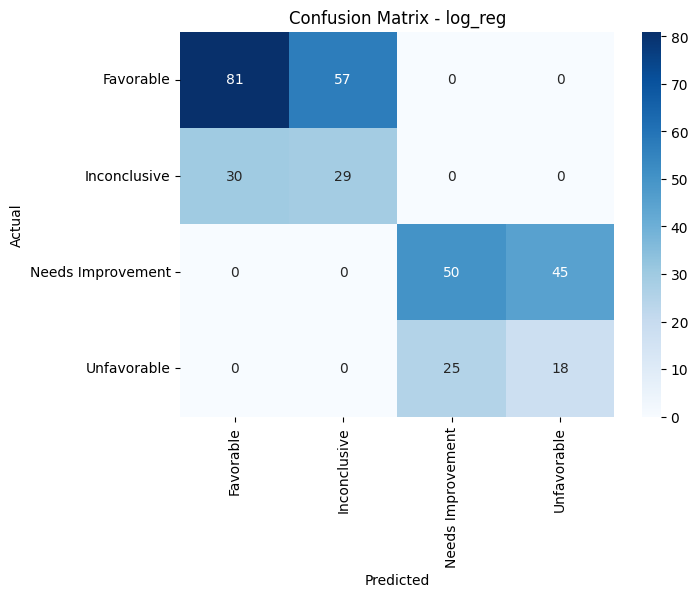

In [20]:
# 5) Evaluation and selection
best_name = results.iloc[0]["model"]
best_model = candidate_models[best_name]

predictive_model = Pipeline([("prep", preprocessor), ("model", best_model)])
predictive_model.fit(X_train, y_train)
pred = predictive_model.predict(X_test)

print("Selected predictive model:", best_name)
print("Macro F1:", round(f1_score(y_test, pred, average="macro"), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=sorted(y.unique()))
cm_df = pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique()))
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [21]:
# 5-6) Fairness check and feature selection insights
# Fairness proxy: compare accuracy by location_visited subgroup.
test_df = X_test.copy().reset_index(drop=True)
test_df["y_true"] = y_test.reset_index(drop=True)
test_df["y_pred"] = pd.Series(pred)

group_perf = (
    test_df.groupby("location_visited")
    .apply(lambda g: (g["y_true"] == g["y_pred"]).mean())
    .rename("group_accuracy")
    .sort_values(ascending=False)
)
print("Group-level accuracy by location_visited")
print(group_perf)

# Permutation importance on test set for the selected predictive model.
# For sklearn pipelines, importances are returned for ORIGINAL input columns.
perm = permutation_importance(
    predictive_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
)

feature_names = X_test.columns
imp = pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
imp = imp.sort_values("importance", ascending=False)

top_features = imp.head(15).copy()
top_features.to_csv(ARTIFACTS_DIR / "home_visitations_top_features.csv", index=False)

top_features.head(10)

Group-level accuracy by location_visited
location_visited
Community Center        0.629630
Church                  0.600000
School                  0.541667
Barangay Office         0.535714
Family Home             0.465517
Proposed Foster Home    0.400000
Name: group_accuracy, dtype: float64


,feature,importance
6,follow_up_needed,0.246997
2,location_visited,0.013283
5,safety_concerns_noted,0.012655
1,visit_type,0.011685
11,cooperation_score,0.011218
0,social_worker,0.006632
8,visit_month,0.003694
4,family_cooperation_level,0.001482
9,visit_dow,0.001342
10,family_present_count,-0.000241


In [22]:
# 7) Deployment-ready artifacts and decision recommendations
import joblib

joblib.dump(predictive_model, ARTIFACTS_DIR / "home_visitations_predictive_model.joblib")
joblib.dump(causal_model, ARTIFACTS_DIR / "home_visitations_explanatory_model.joblib")

schema = {
    "target": TARGET,
    "features": X.columns.tolist(),
    "categorical_features": cat_cols,
    "numeric_features": num_cols,
    "selected_predictive_model": best_name,
    "metrics": {
        "macro_f1": float(f1_score(y_test, pred, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
    },
}

with open(ARTIFACTS_DIR / "home_visitations_model_schema.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)

print("Saved artifacts:")
print("-", ARTIFACTS_DIR / "home_visitations_predictive_model.joblib")
print("-", ARTIFACTS_DIR / "home_visitations_explanatory_model.joblib")
print("-", ARTIFACTS_DIR / "home_visitations_top_features.csv")
print("-", ARTIFACTS_DIR / "home_visitations_model_schema.json")

print("\nDecision recommendations (template based on top drivers):")
for i, feat in enumerate(top_features.head(5)["feature"], start=1):
    print(f"{i}. Monitor '{feat}' closely in case reviews and triage workflows.")
print("6. Use predicted high-risk cases (low expected outcome) for earlier follow-up assignment.")

Saved artifacts:
- artifacts\home_visitations_predictive_model.joblib
- artifacts\home_visitations_explanatory_model.joblib
- artifacts\home_visitations_top_features.csv
- artifacts\home_visitations_model_schema.json

Decision recommendations (template based on top drivers):
1. Monitor 'follow_up_needed' closely in case reviews and triage workflows.
2. Monitor 'location_visited' closely in case reviews and triage workflows.
3. Monitor 'safety_concerns_noted' closely in case reviews and triage workflows.
4. Monitor 'visit_type' closely in case reviews and triage workflows.
5. Monitor 'cooperation_score' closely in case reviews and triage workflows.
6. Use predicted high-risk cases (low expected outcome) for earlier follow-up assignment.


## Notes

- This notebook intentionally separates explanatory and predictive goals.
- If your course requires a strict causal claim, add stronger design assumptions (or quasi-experimental methods).
- For web app integration, load `home_visitations_predictive_model.joblib` and enforce `home_visitations_model_schema.json` at inference time.